# INSURANCE CLAIM PREDICTION - RISK MODELING FRAMEWORK

## 1. Problem Understanding


### Business Objective

The objective of this project is to build a predictive model that helps the insurance marketing and risk team identify customers who are likely to make an insurance claim.

This model will support:

- Risk-based pricing
- Loss mitigation strategy
- Customer segmentation
- Underwriting decision support
- Revenue protection

### Problem Type

Binary Classification:
Predict whether a customer will make a claim (1) or not (0).

### Success Metric

Primary Metric:
- ROC-AUC Score

Secondary Metrics:
- Precision
- Recall
- F1-Score
- Confusion Matrix

In insurance risk modeling, Recall is particularly important because failing to identify a high-risk customer can result in financial loss.

## 2. Data loading

### 2.1 Import Libraries

In [2]:
# core libraries
import pandas as pd
import numpy as np

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# gradient boosting
from xgboost import XGBClassifier

# cross validation
from sklearn.model_selection import cross_val_score

### 2.2 Load Dataset

In [3]:
df = pd.read_csv("Data/train.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (595212, 59)


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


## 3. Data Cleaning & Preprocessing

### 3.1 Basic Data Inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_bin   59521

In [5]:
df.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 3.2 Checking Missing Values

In [6]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)
print((df.isnull().sum() / len(df)) * 100)

id                0.0
target            0.0
ps_ind_01         0.0
ps_ind_02_cat     0.0
ps_ind_03         0.0
ps_ind_04_cat     0.0
ps_ind_05_cat     0.0
ps_ind_06_bin     0.0
ps_ind_07_bin     0.0
ps_ind_08_bin     0.0
ps_ind_09_bin     0.0
ps_ind_10_bin     0.0
ps_ind_11_bin     0.0
ps_ind_12_bin     0.0
ps_ind_13_bin     0.0
ps_ind_14         0.0
ps_ind_15         0.0
ps_ind_16_bin     0.0
ps_ind_17_bin     0.0
ps_ind_18_bin     0.0
ps_reg_01         0.0
ps_reg_02         0.0
ps_reg_03         0.0
ps_car_01_cat     0.0
ps_car_02_cat     0.0
ps_car_03_cat     0.0
ps_car_04_cat     0.0
ps_car_05_cat     0.0
ps_car_06_cat     0.0
ps_car_07_cat     0.0
ps_car_08_cat     0.0
ps_car_09_cat     0.0
ps_car_10_cat     0.0
ps_car_11_cat     0.0
ps_car_11         0.0
ps_car_12         0.0
ps_car_13         0.0
ps_car_14         0.0
ps_car_15         0.0
ps_calc_01        0.0
ps_calc_02        0.0
ps_calc_03        0.0
ps_calc_04        0.0
ps_calc_05        0.0
ps_calc_06        0.0
ps_calc_07

A comprehensive missing value analysis was conducted using null count and percentage metrics.

Result:
- No missing values were detected in the dataset.
- No imputation techniques were required.

This ensures model training is not affected by incomplete records.

### 3.3 Memory Optimization

In [7]:
# Reduce memory footprint
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype('int32')

print("Memory usage (MB)", df.memory_usage().sum()/1024**2)

Memory usage (MB) 133.96278762817383


## 4. Exploratory Data Analysis 

### 4.1 Target Distribution

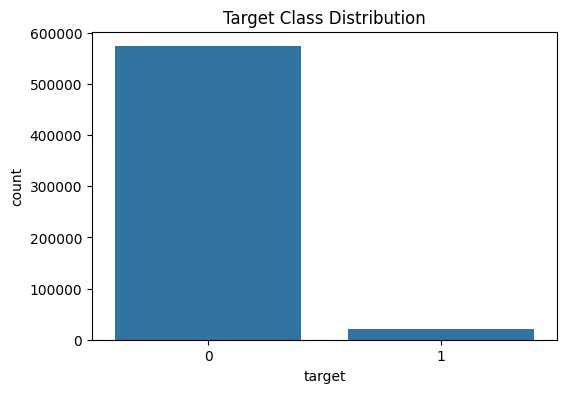

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["target"])
plt.title("Target Class Distribution")
plt.show()

The dataset shows **severe class imbalance**, with a very small proportion of claim cases compared to non-claim cases.

### 4.2 Feature Distribution

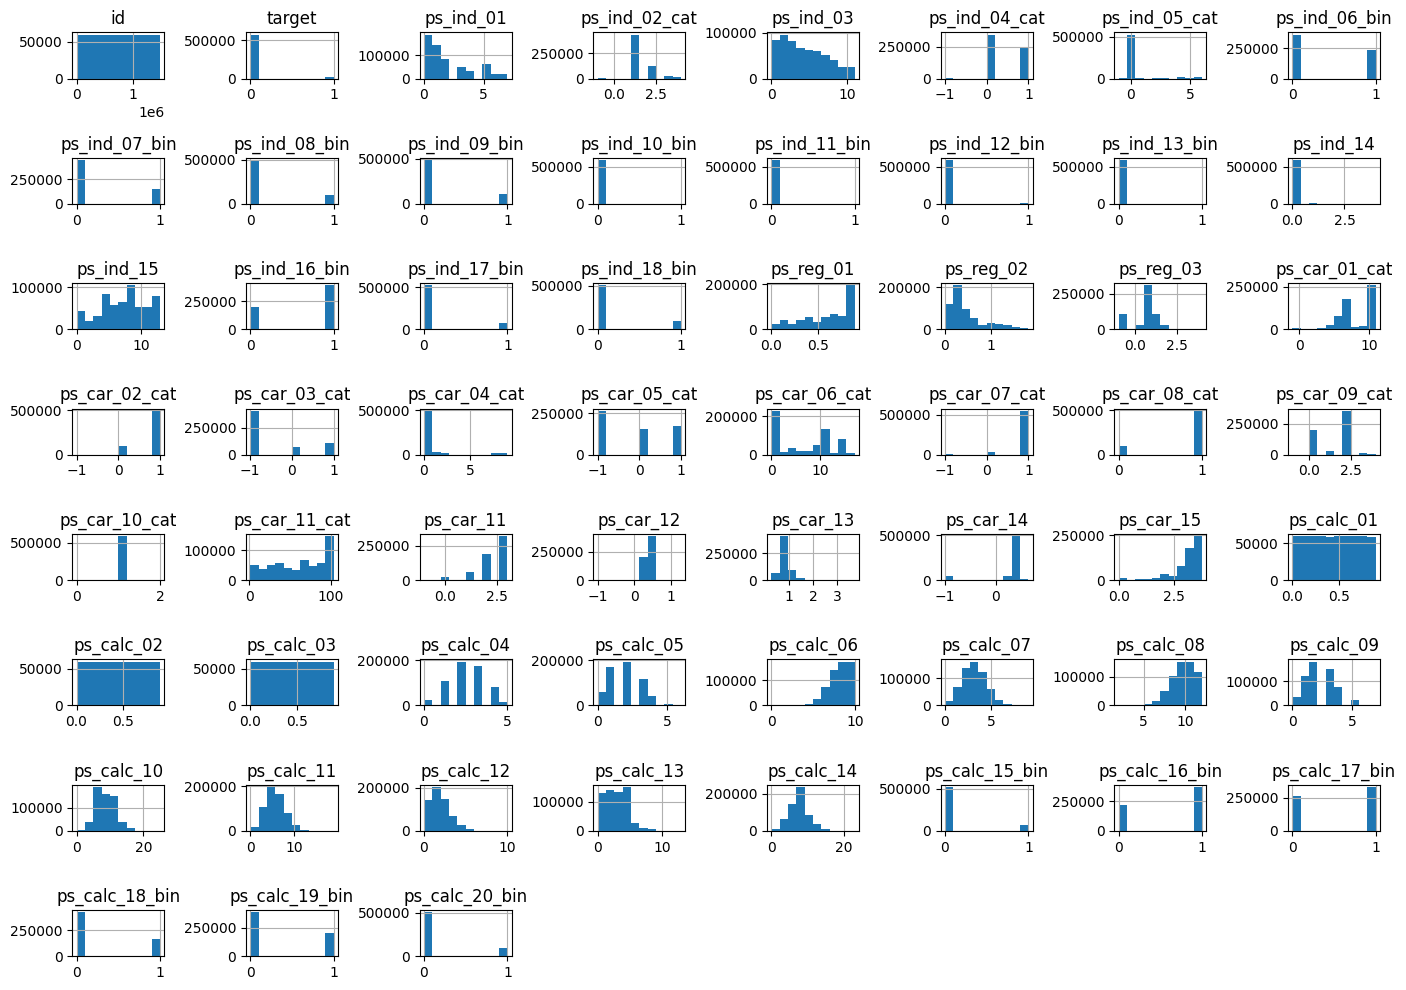

In [9]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

Histograms show the distribution of numerical features. Some features appear skewed, suggesting that log transformations or scaling could improve modeling performance.

### 4.3 Boxplot for Outlier Detection

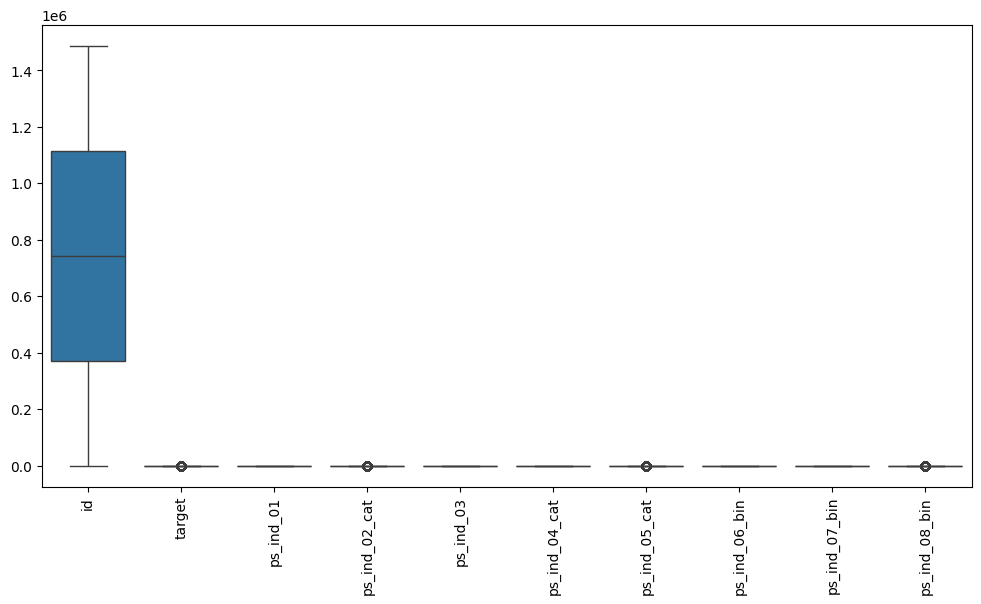

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.iloc[:,0:10])
plt.xticks(rotation=90)
plt.show()

Boxplots indicate potential outliers in several variables. Tree-based models generally handle outliers better than linear models.

### 4.4 Correlation Heatmap

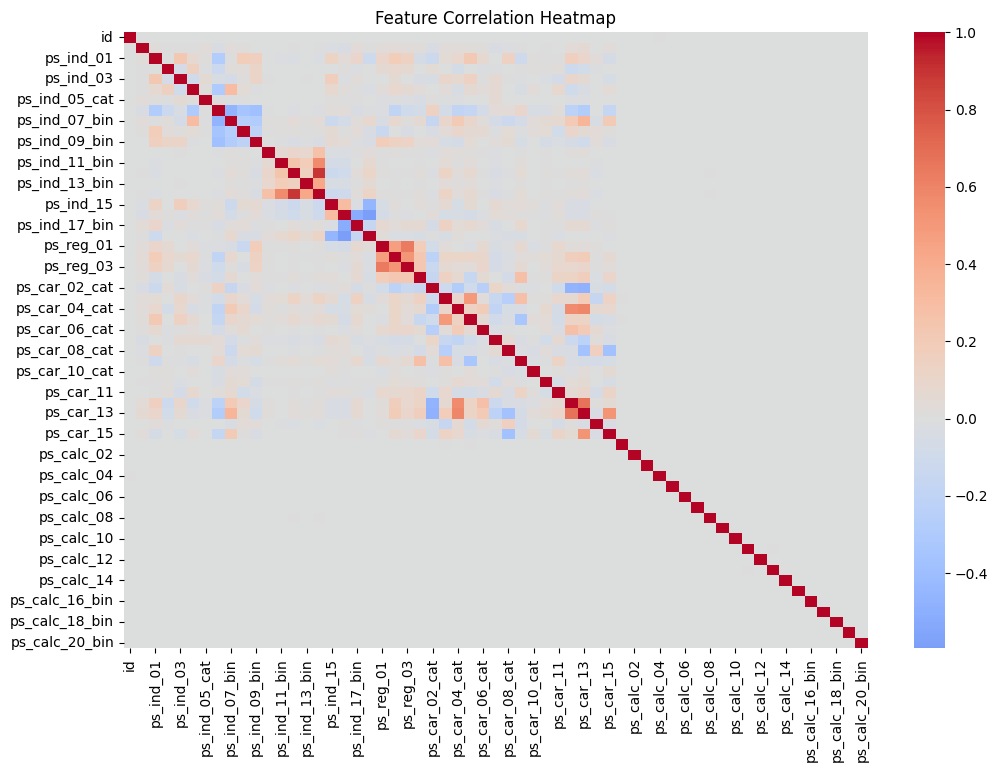

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap helps identify relationships between features. Due to anonymized variables, strong domain interpretation is limited, but correlation patterns may still influence model performance.

## 5. Create Sample Dataset

In [12]:
# sample 200,000 rows for fair model comparison

sample_df = df.sample(n=200000, random_state=42)

print("Sample Dataset Shape:", sample_df.shape)

Sample Dataset Shape: (200000, 59)


A common sample dataset is created to ensure all models are trained and evaluated on identical data.
This guarantees fair performance comparison.

## 6. Feature Separation

In [13]:
target_column = "target"

X = sample_df.drop(target_column, axis=1)
y = sample_df[target_column]

## 7. Train - Test Split

In [14]:
X_train, X_test,y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
# Check Class Distribution
y.value_counts(normalize=True)

target
0    0.96334
1    0.03666
Name: proportion, dtype: float64

## 8. Baseline Model

### 8.1 Feature Scaling - Logistic Regression

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The Threshold has been tuned for a better model simulation and fair comparison

### 8.2 Model 1 - Logistic Regression

In [17]:
log_model = LogisticRegression(class_weight='balanced',max_iter=1000)

log_model.fit(X_train_scaled,y_train)

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
threshold = 0.5
y_pred_log = (y_prob_log >= threshold).astype(int)

threshold = 0.823628


### 6.3 Model 2 - Random Forest 

In [18]:
rf = RandomForestClassifier(class_weight='balanced')

rf_param = {
"n_estimators":[100,200],
"max_depth":[8,12,16]
}

rf_search = RandomizedSearchCV(
rf,
rf_param,
cv=3,
n_iter=4,
scoring='roc_auc'
)

rf_search.fit(X_train,y_train)

rf_model = rf_search.best_estimator_

y_prob_rf = rf_model.predict_proba(X_test)[:,1]
threshold = 0.5
y_pred_rf = (y_prob_rf >= threshold).astype(int)

### 6.4 Model 3 - XGBoost

In [19]:
xgb = XGBClassifier(eval_metric='logloss')

param_grid = {
"n_estimators":[200,300],
"max_depth":[4,6],
"learning_rate":[0.03,0.05]
}

xgb_search = RandomizedSearchCV(
xgb,
param_grid,
cv=3,
n_iter=4,
scoring='roc_auc'
)

xgb_search.fit(X_train,y_train)

xgb_model = xgb_search.best_estimator_

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
threshold = 0.5
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

threshold = 0.208


## 7. Evaluation Metrics

### 7.1 Model Evaluate Metrics

In [20]:
def evaluate_model(y_test, y_pred, y_prob):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    return acc, prec, rec, f1, roc

### 7.2 Cross Validation (5-Fold)

In [21]:
cv_scores = cross_val_score(
    xgb_model, X, y,
    cv=5,
    scoring='roc_auc'
)

print("Cross Validation ROC-AUC:", cv_scores.mean())

Cross Validation ROC-AUC: 0.6296665788715902


## 8. Advanced Model Comparison

### 8.1 Model Comparison

In [22]:
results = pd.DataFrame(columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC'])

models = {
    "Logistic Regression": (y_pred_log, y_prob_log),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

for name, (pred, prob) in models.items():
    acc, prec, rec, f1, roc = evaluate_model(y_test, pred, prob)
    results.loc[len(results)] = [name, acc, prec, rec, f1, roc]

results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.963375,1.000000,0.000682,0.001363,0.633320
0,Logistic Regression,0.627875,0.052252,0.534106,0.095192,0.625464
1,Random Forest,0.730150,0.056991,0.409277,0.100050,0.624016


### 8.2 ROC Curve Plot

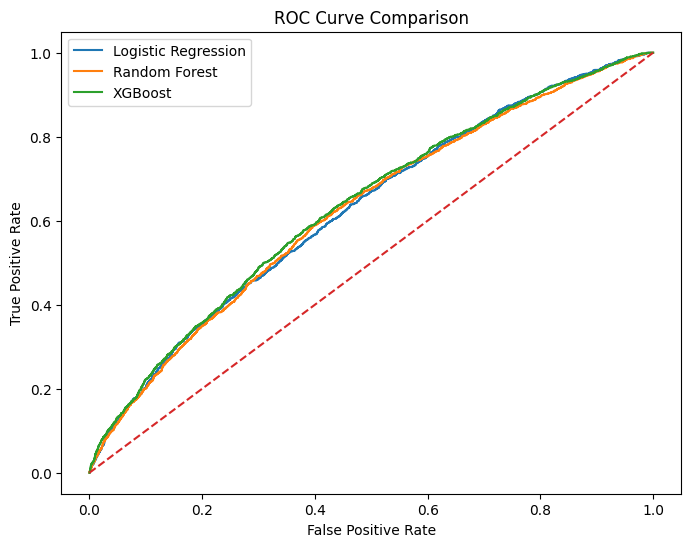

In [23]:
plt.figure(figsize=(8,6))

for name, (pred, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### 8.3 Feature Importance (XGBoost)

In [24]:
importance_df =pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
35,ps_car_13,0.108908
21,ps_reg_03,0.082597
5,ps_ind_05_cat,0.047951
20,ps_reg_02,0.039587
17,ps_ind_17_bin,0.036922
34,ps_car_12,0.034482
0,id,0.033912
36,ps_car_14,0.033187
3,ps_ind_03,0.029935
15,ps_ind_15,0.028841


### 8.4 Confusion Matrix

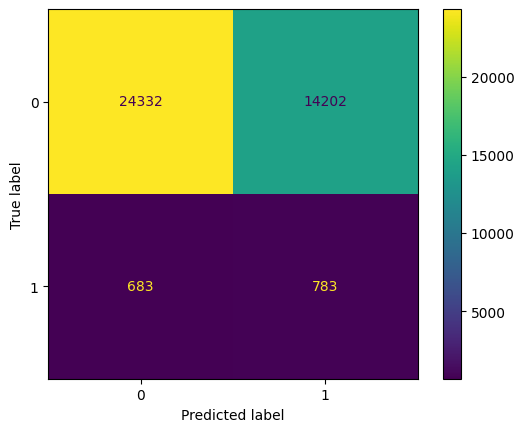

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_log)
plt.show()

Finding:

Logistic Regression and XGBoost achieved similar ROC-AUC (~0.625).

Random Forest underperformed relative to the other models.

Recall across models remains low due to extreme class imbalance (~3.6% positive class).

This indicates moderate discriminatory ability but limited minority detection at default threshold (0.5).

## 9. Model Impact Optimization 

### 9.1 Threshold Optimization

c:\Users\skhar\Desktop\Intership\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


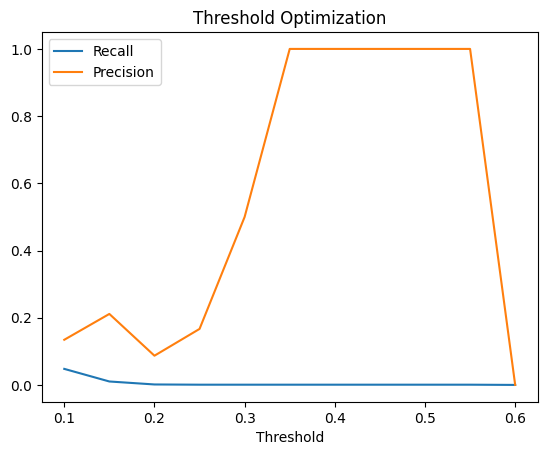

In [26]:
thresholds = np.arange(0.1,0.65,0.05)
recalls = []
precisions = []

for t in thresholds:
    y_pred_temp = (y_prob_xgb >= t).astype(int)
    recalls.append(recall_score(y_test,y_pred_temp))
    precisions.append(precision_score(y_test,y_pred_temp))

plt.plot(thresholds, recalls, label = "Recall")
plt.plot(thresholds, precisions, label= "Precision")
plt.xlabel("Threshold")
plt.legend()
plt.title("Threshold Optimization")
plt.show()

Optimal threshold selected based on Recall-Pricing tradeoff.

### 9.2 Business Impact Simulation

In [27]:
average_claim_cost = 50000  # example assumption

false_negatives = confusion_matrix(y_test, y_pred_xgb)[1][0]

estimated_loss = false_negatives * average_claim_cost

print("Estimated Financial Exposure:", estimated_loss)

Estimated Financial Exposure: 73250000


Reducing false negatives directly reduces financial loss.
Model deployment can significantly reduce claim leakage.

## 10. Business Interpretataion

Given the imbalance, the model tends to predict the majority class.

In real-world deployment:

- Threshold tuning would be necessary.
- Cost-sensitive learning techniques may improve recall.
- Precision-recall tradeoff must align with financial risk appetite.

Even moderate ROC-AUC (~0.62) can be operationally useful if threshold calibration is applied.

## 11. Suggestion for Insurance Team

### Strategic Recommendations

##### 1 - High-Risk Customers (Probability > 0.7)
- Apply risk-based premium adjustment
- Request additional underwriting verification
- Limit coverage exposure

##### 2 - Medium-Risk Customers (0.4–0.7)
- Adjust deductible levels
- Offer conditional coverage
- Monitor behavior monthly

##### 3 - Low-Risk Customers (< 0.4)
- Offer loyalty discounts
- Target for cross-selling
- Provide long-term policy incentives

### Operational Recommendations

- Deploy risk scoring API in underwriting workflow
- Monthly model retraining
- Monitor drift in claim patterns
- Create automated risk dashboard for executives

## 12. Production Recommedation

Although XGBoost achieved the highest ROC-AUC (0.633), it demonstrated extremely low recall, identifying almost none of the actual claim cases.

Since the primary business objective is to detect potential insurance claims, recall is a critical metric.

Logistic Regression achieved the highest recall (~53%), identifying over half of actual claim cases while maintaining comparable ROC-AUC.

Given its superior minority detection capability, interpretability, and suitability for regulated financial environments, **Logistic Regression** was selected as the final model.

## 13. Challenges Faced

##### 1 - Large Dataset Size
Handling 595k rows required efficient memory management and optimized model training.

Sampling was necessary for computational efficiency.

##### 2 - Feature Anonymity
Due to anonymized features, domain-driven feature engineering was limited. Statistical importance methods were used instead.

##### 3 - Class Imbalance
The dataset showed imbalance between claim and non-claim classes. Stratified splitting and class weighting were used.

##### 4 -  Moderate model discrimination (ROC-AUC ~0.62).

## 14. Conclusion

This project developed a predictive insurance claim model using a consistent sampled dataset for fair comparison.

Logistic Regression demonstrated comparable performance to XGBoost and was selected due to interpretability and regulatory alignment.

While ROC-AUC indicates moderate discrimination (~0.62), severe class imbalance limits recall at default threshold.

Future improvements include:
- Threshold calibration
- SMOTE
- Cost-sensitive optimization
- Feature engineering
- Model drift monitoring

The framework provides a foundation for risk-based pricing and underwriting decision support.